# Performing a focal scan using geometric optics and diffraction with the Collins propagators

In this tutorial, we simulate the propagation of a focusing continuous-wave (CW) beam in free-space. This gives an overview of the functionality of the `CollinsSFFTPropagator` and the `CollinsDFFTPropagator` classes which define diffraction integrals expressed in terms of an optical ray matrix. The optical ray matrix is defined in the `ABCD` class. 

The `CollinsSFFTPropagator` is based on a single fast-Fourier transform (SFFT) and is used to go between the near-field (NF) and the far-field (FF) in imaging systems. The `CollinsDFFTPropagator` is based on a double fast-Fourier transform (DFFT) and is therefore more suited to going between planes within either domain.

This tutorial gives an overview of how to use `ABCD` define the optical ray matrices for basic components such as thin-lenses and drift sections in vacuum. A tophat CW beam is propagated to the first plane of the focal scan using the `CollinsSFFTPropagator`, where a lens and free-space drift are defined using `ABCD` matrices. The `CollinsDFFTPropagator` is then used to propagate this beam to subsequent planes in the focal scan.

First we import a few relevant modules: 

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.axes_grid1 import make_axes_locatable
from scipy.constants import c, epsilon_0

from lasy.laser import Laser
from lasy.profiles import CombinedLongitudinalTransverseProfile
from lasy.profiles.longitudinal import ContinuousWaveProfile
from lasy.profiles.transverse import SuperGaussianTransverseProfile
from lasy.propagators import ABCD, CollinsDFFTPropagator, CollinsSFFTPropagator

ModuleNotFoundError: No module named 'lasy'

Next, we define the beam to be continous wave with a tophat profile in the transverse plane:

In [ ]:
peak_fluence = 1.0e4  # J/m^2
spot_size = 10e-3
wavelength = 800e-9
omega0 = 2 * np.pi * c / wavelength
pol = (1, 0)

long_prof = ContinuousWaveProfile(wavelength)
tran_prof = SuperGaussianTransverseProfile(spot_size, 10)
laser_profile = CombinedLongitudinalTransverseProfile(
    wavelength, pol, long_prof, tran_prof, peak_fluence=peak_fluence
)

We now define the grids at the input plane and the full laser object in terms of the grid and the laser:

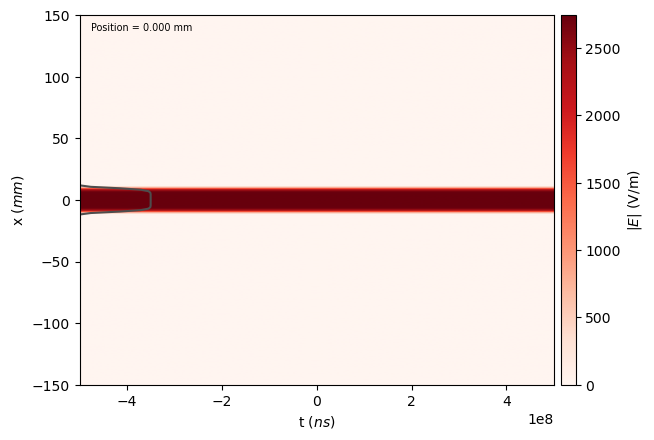

In [3]:
dimensions = "xyt"  # Use cylindrical geometry
lo = (-15.0 * spot_size, -15.0 * spot_size, None)  # Lower bounds of the simulation box
hi = (15.0 * spot_size, 15.0 * spot_size, None)  # Upper bounds of the simulation box
num_points = (255, 255, 1)  # Number of points in each dimension

laser = Laser(dimensions, lo, hi, num_points, laser_profile)
laser.show()

We will now set up the focal scan by estimating the Rayleigh length and using this to define the axial grid:

In [4]:
focal_length = 300e-3
z_R = (
    np.pi * spot_size**2 / (wavelength * focal_length**2)
)  # The estimated Rayleigh length after the lens
limits = [-2.0 * 1e-3, 2.0 * 1e-3]  # Set the depth limits for the focal scan
N_points = 200

z_grid = (
    np.linspace(limits[0], limits[1], N_points) + focal_length
)  # Absolute axial distances from the input plane of the lens

We will now make a copy of the laser and define both the SFFT and DFFT propagators that we will use in our focal scan. We then initialise the ABCD matrix and add a thin-lens of the correct focal length:

In [5]:
prop_s = CollinsSFFTPropagator(dimensions, omega0)
prop_d = CollinsDFFTPropagator(dimensions, omega0)
abcd = ABCD()
abcd.add_lens(focal_length)

Now we will perform the focal scan (see comments within the loop for an explanation of intermediate steps):

In [6]:
focal_scan = []  # Create empty list to store the focal scan data

for i, z in enumerate(z_grid):
    print("Step %i of %i" % (i, len(z_grid)))
    if i == 0:
        abcd.add_vacuum(
            z
        )  # Add the drift that takes us to the closest plane of the focal scan
        prop_s.propagate(
            laser.grid, abcd
        )  # Propagate from the lens to the first plane using the SFFT
    else:
        abcd = ABCD()  # Clear the ABCD matrix...
        abcd.add_vacuum(
            z - z_grid[i - 1]
        )  # And define only the drift distance between the current plane and the previous one
        prop_d.propagate(
            focal_scan[0].grid, abcd, grid_out=focal_scan[0].grid
        )  # Propagate to the next plane in the scan using the DFFT

    focal_scan.append(laser)  # Storing the full focal scan data

    lineout = (
        c
        * epsilon_0
        / 2
        * np.abs(laser.grid.get_temporal_field()[num_points[0] // 2, :, 0]) ** 2
    )  # Take an intensity lineout in one transverse plane

    # Stack these lineouts to plot a cross-section of the focal scan
    if i == 0:
        scanImg = lineout
    else:
        scanImg = np.vstack((scanImg, lineout))

Step 0 of 200
fft of size 1: do nothing
fft of size 1: do nothing
Step 1 of 200
fft of size 1: do nothing
Step 2 of 200
fft of size 1: do nothing
Step 3 of 200
fft of size 1: do nothing
Step 4 of 200
fft of size 1: do nothing
Step 5 of 200
fft of size 1: do nothing
Step 6 of 200
fft of size 1: do nothing
Step 7 of 200
fft of size 1: do nothing
Step 8 of 200
fft of size 1: do nothing
Step 9 of 200
fft of size 1: do nothing
Step 10 of 200
fft of size 1: do nothing
Step 11 of 200
fft of size 1: do nothing
Step 12 of 200
fft of size 1: do nothing
Step 13 of 200
fft of size 1: do nothing
Step 14 of 200
fft of size 1: do nothing
Step 15 of 200
fft of size 1: do nothing
Step 16 of 200
fft of size 1: do nothing
Step 17 of 200
fft of size 1: do nothing
Step 18 of 200
fft of size 1: do nothing
Step 19 of 200
fft of size 1: do nothing
Step 20 of 200
fft of size 1: do nothing
Step 21 of 200
fft of size 1: do nothing
Step 22 of 200
fft of size 1: do nothing
Step 23 of 200
fft of size 1: do nothing


We will now get the output grids from the simulation and plot a cross-section of the focal scan

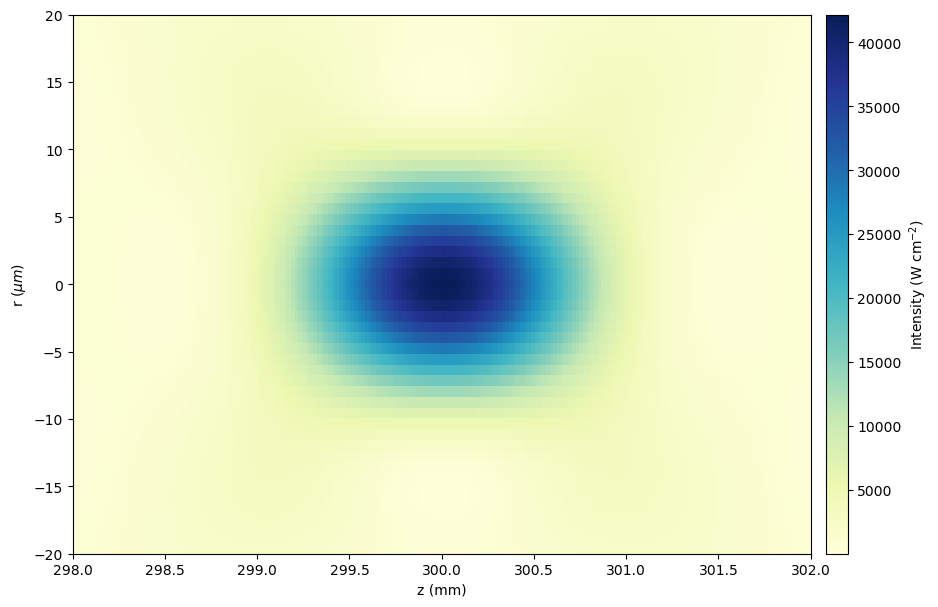

In [7]:
# Get the grids from the simulation
x_grid = focal_scan[0].grid.axes[
    0
]  # Output axes as automatically calculated by the CollinsSFFTPropagator
y_grid = focal_scan[0].grid.axes[1]
extent = [z_grid[0] * 1e3, z_grid[-1] * 1e3, y_grid[0] * 1e6, y_grid[-1] * 1e6]

# Make plot of focal scan cross-section
fig, ax = plt.subplots(1, 1, figsize=(10, 7))
ax_divider = make_axes_locatable(ax)
im = ax.imshow(
    scanImg.T / 1e4, aspect="auto", interpolation="none", cmap="YlGnBu", extent=extent
)
cax = ax_divider.append_axes("right", size="3%", pad="2%")
cb = fig.colorbar(im, cax=cax)
cb.set_label(r"Intensity (W cm$^{-2}$)")
ax.set_xlabel("z (mm)")
ax.set_ylabel(r"r ($\mu m$)")
ax.set_ylim(-20, 20)
plt.show()